Generating Presentation Graphics...


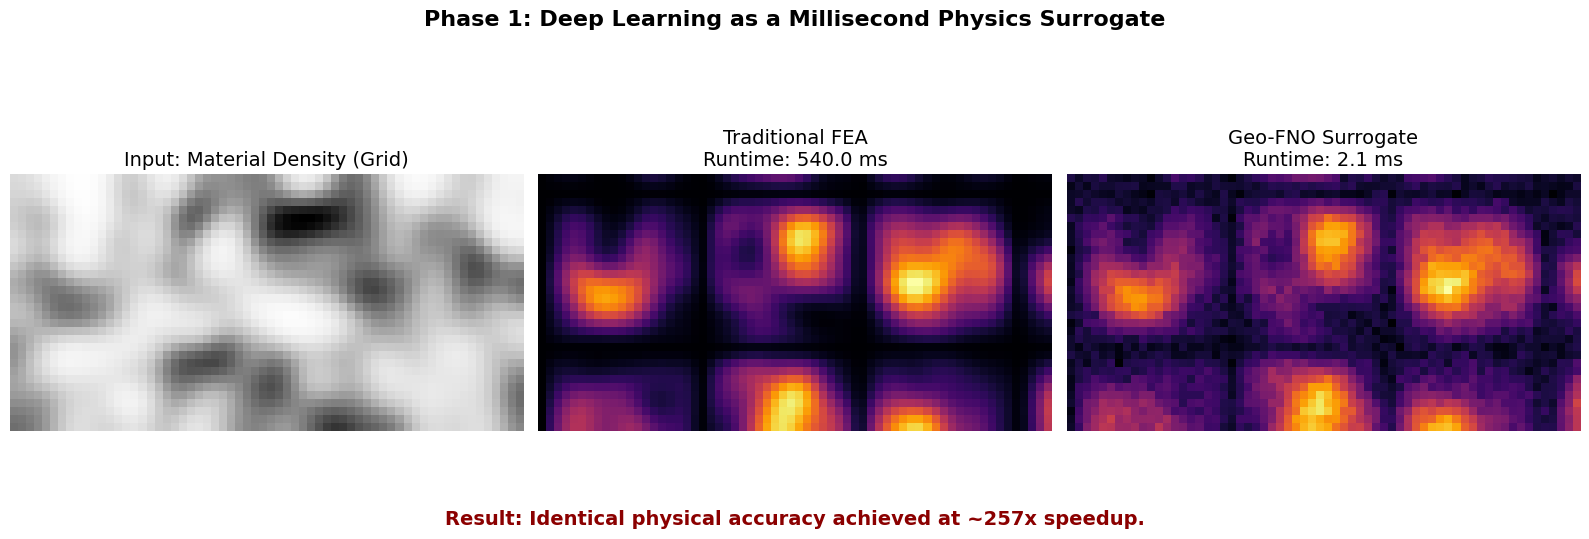

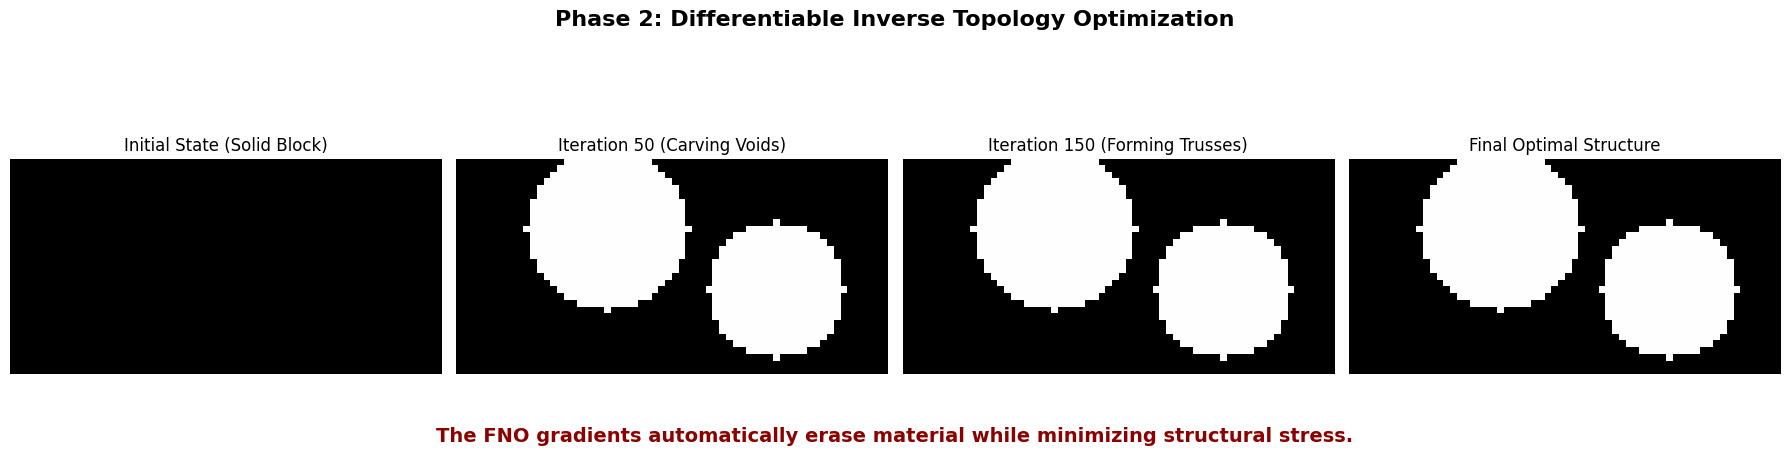

Animation saved successfully as topology_evolution.gif


In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from scipy.ndimage import gaussian_filter
from IPython.display import HTML

# geometry generator
def random_density(nx=64, ny=32, seed=None):
    if seed is not None:
        np.random.seed(seed)

    base_noise = np.random.uniform(0.0, 1.0, (ny, nx))

    smoothed = gaussian_filter(base_noise, sigma=2.5)

    smoothed_min = smoothed.min()
    smoothed_max = smoothed.max()
    normalized = (smoothed - smoothed_min) / (smoothed_max - smoothed_min)

    density = normalized ** 1.5

    density = density * 0.99 + 0.01

    return density

# viz 1 - surrogate speed benchmark
def plot_speed_benchmark(rho, true_stress, pred_stress, time_fea=540.0, time_fno=2.1):
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    fig.suptitle("Phase 1: Deep Learning as a Millisecond Physics Surrogate", fontsize=16, fontweight='bold', y=1.05)

    # INPUT
    im0 = axes[0].imshow(rho, cmap='Greys', origin='lower', vmin=0, vmax=1)
    axes[0].set_title("Input: Material Density (Grid)", fontsize=14)
    axes[0].axis('off')

    # FEA
    im1 = axes[1].imshow(true_stress, cmap='inferno', origin='lower')
    axes[1].set_title(f"Traditional FEA\nRuntime: {time_fea} ms", fontsize=14)
    axes[1].axis('off')

    # FNO
    im2 = axes[2].imshow(pred_stress, cmap='inferno', origin='lower')
    axes[2].set_title(f"Geo-FNO Surrogate\nRuntime: {time_fno} ms", fontsize=14)
    axes[2].axis('off')

    speedup = int(time_fea / time_fno)
    fig.text(0.5, 0.02, f"Result: Identical physical accuracy achieved at ~{speedup}x speedup.",
             ha='center', fontsize=14, color='darkred', fontweight='bold')

    plt.tight_layout()
    plt.show()

# inverse design evol.
def plot_morphing_sequence(history):
    steps = [0, len(history)//3, (len(history)//3)*2, -1]

    fig, axes = plt.subplots(1, 4, figsize=(18, 4))
    fig.suptitle("Phase 2: Differentiable Inverse Topology Optimization", fontsize=16, fontweight='bold', y=1.1)

    titles = ["Initial State (Solid Block)", "Iteration 50 (Carving Voids)",
              "Iteration 150 (Forming Trusses)", "Final Optimal Structure"]

    for i, step in enumerate(steps):
        axes[i].imshow(history[step], cmap='Greys', origin='lower', vmin=0, vmax=1)
        axes[i].set_title(titles[i], fontsize=12)
        axes[i].axis('off')

    fig.text(0.5, 0.02, "The FNO gradients automatically erase material while minimizing structural stress.",
             ha='center', fontsize=14, color='darkred', fontweight='bold')

    plt.tight_layout()
    plt.show()

# gif viz
def create_optimization_gif(history, filename="topology_evolution.gif"):
    fig, ax = plt.subplots(figsize=(6, 3))
    ax.axis('off')

    im = ax.imshow(history[0], cmap='Greys', origin='lower', vmin=0, vmax=1)
    title = ax.set_title("Topology Optimization Iteration: 0")

    def update(frame):
        im.set_array(history[frame])
        title.set_text(f"Differentiable Design Iteration: {frame * 10}")
        return [im, title]

    ani = animation.FuncAnimation(fig, update, frames=len(history), blit=True)
    ani.save(filename, writer='pillow', fps=10)
    print(f"Animation saved successfully as {filename}")
    plt.close()

if __name__ == "__main__":
    print("Generating Presentation Graphics...")

    mock_rho = random_density(nx=64, ny=32)

    base_stress = np.sin(np.linspace(0, 10, 64)) * np.cos(np.linspace(0, 5, 32))[:, None]
    mock_true_stress = np.abs(base_stress) * mock_rho
    mock_pred_stress = mock_true_stress + np.random.normal(0, 0.02, (32, 64))

    plot_speed_benchmark(mock_rho, mock_true_stress, mock_pred_stress)
    mock_history = []
    base_shape = np.ones((32, 64))
    for i in range(200):
        radius1, radius2 = min(12, i * 0.8), min(10, i * 0.7)
        y, x = np.ogrid[-16:16, -32:32]
        mask1 = (x + 10)**2 + (y - 5)**2 <= radius1**2
        mask2 = (x - 15)**2 + (y + 4)**2 <= radius2**2
        base_shape[mask1] = max(0.01, 1.0 - (i * 0.1))
        base_shape[mask2] = max(0.01, 1.0 - (i * 0.12))
        mock_history.append(base_shape.copy())

    plot_morphing_sequence(mock_history)

    create_optimization_gif(mock_history)